Vigtigste ændringer:

- bruger pooled healthy training data T1/T2/T3
- vælger PCA-komponenter efter fx 90% forklaret varians
- vælger DPCA-komponenter efter 90% forklaret varians
- skifter thresholds fra 95% til 99%
- laver tosidet Shewhart-limit
- Shewhart evalueres kun én gang, efter fault/test data er transformeret med samme preprocessor som training data
- fjerner case-specifikt sensorvalg i Shewhart, så evalueringen ikke bruger fault-viden
- beholder train/test separation med preprocessor.transform() på fault data
- bruger stadig dine korrekte PCA/DPCA transform- og statistikfunktioner


# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

## Faulty cases - Ground truth
We know the start and end times of the faults in the different cases which serves as a ground truth to compare the results with.

In [1]:
SEfc1_1 = [1566, 5181] # Fault start and end for FaultyCase1 set 1.1
SEfc1_2 = [657, 3777]
SEfc1_3 = [691, 3691]

SEfc2_1 = [2244, 6616]
SEfc2_2 = [476, 2656]
SEfc2_3 = [331, 2467]

SEfc3_1 = [1136, 8352]
SEfc3_2 = [333, 5871]
SEfc3_3 = [596, 9566]

SEfc4_1 = [953, 6294]
SEfc4_2 = [851, 3851]
SEfc4_3 = [241, 3241]

SEfc5_1 = [686, 1172, 1772, 2253] # Fault start and end for FaultyCase5 set 5.1 with two faults
SEfc5_2 = [1633, 2955, 7031, 7553, 8057, 10608] # with three faults

SEfc6_1 = [1723, 2800]
SEfc6_2 = [1037, 4830]

# cases, sets, and their corresponding fault windows
se_windows = {
    "FaultyCase1": {"Set1_1": SEfc1_1, "Set1_2": SEfc1_2, "Set1_3": SEfc1_3},
    "FaultyCase2": {"Set2_1": SEfc2_1, "Set2_2": SEfc2_2, "Set2_3": SEfc2_3},
    "FaultyCase3": {"Set3_1": SEfc3_1, "Set3_2": SEfc3_2, "Set3_3": SEfc3_3},
    "FaultyCase4": {"Set4_1": SEfc4_1, "Set4_2": SEfc4_2, "Set4_3": SEfc4_3},
    "FaultyCase5": {"Set5_1": SEfc5_1, "Set5_2": SEfc5_2},
    "FaultyCase6": {"Set6_1": SEfc6_1, "Set6_2": SEfc6_2}
}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fdd.dataloader import DataLoader
from fdd.dataset import TimeSeriesDataset
from fdd.preprocessor import StandardPreprocessor
from fdd.pca import pca_fit, pca_transform
from fdd.dpca import build_lagged_matrix, dpca_fit, dpca_transform, dpca_prepare_matrix
from fdd.statistics import q_statistic, t2_statistic
from fdd.fda import FDAModel


In [3]:
def normalize_fault_windows(window):
    """Convert [start, end, start, end, ...] to [(start, end), ...]."""
    if len(window) % 2 != 0:
        raise ValueError(f"Fault window must contain start/end pairs. Got: {window}")
    return [(int(window[i]), int(window[i + 1])) for i in range(0, len(window), 2)]


def is_in_fault_window(samples, windows):
    """Boolean mask for whether each sample index lies inside any fault window."""
    samples = np.asarray(samples)
    mask = np.zeros(len(samples), dtype=bool)
    for start, end in normalize_fault_windows(windows):
        mask |= (samples >= start) & (samples <= end)
    return mask


def first_detection_delay(alarm_mask, windows, sample_index=None):
    """First alarm delay relative to the first fault start. Uses sample index, not row position."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)

    first_fault_start = normalize_fault_windows(windows)[0][0]
    alarms_after_start = sample_index[alarm_mask & (sample_index >= first_fault_start)]
    if len(alarms_after_start) == 0:
        return np.nan
    return int(alarms_after_start[0] - first_fault_start)


def count_false_alarms(alarm_mask, windows, sample_index=None):
    """Counts alarms outside all labelled fault windows."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)
    fault_mask = is_in_fault_window(sample_index, windows)
    return int(np.sum(alarm_mask & ~fault_mask))


def add_fault_spans(ax, windows, **kwargs):
    """Draw all fault windows on a matplotlib axis."""
    defaults = {"alpha": 0.2}
    defaults.update(kwargs)
    for start, end in normalize_fault_windows(windows):
        ax.axvspan(start, end, **defaults)
        ax.axvline(start, linestyle="--")

def choose_n_components_by_variance(X, target_variance=0.90):
    """Choose PCA components from cumulative eigenvalue variance."""
    max_components = min(X.shape[0] - 1, X.shape[1])
    full_model = pca_fit(X, n_components=max_components)

    eigenvalues = np.asarray(full_model["eigenvalues"])
    positive = eigenvalues[eigenvalues > 0]
    cumulative = np.cumsum(positive) / np.sum(positive)

    return int(np.searchsorted(cumulative, target_variance) + 1)


## Data loading

In [4]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

loader = DataLoader()

# Training data 
trainsets = loader.load("Training")

# Faulty cases (test data)
FC1sets = loader.load("FaultyCase1")
FC2sets = loader.load("FaultyCase2")
FC3sets = loader.load("FaultyCase3")
FC4sets = loader.load("FaultyCase4")
FC5sets = loader.load("FaultyCase5")
FC6sets = loader.load("FaultyCase6")
fc_sets = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets]

In [5]:
fc_sets_raw = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets] # Til FDA

# Training

## Preprocessing

In [6]:
# Centering and scaling
# Use all healthy training sets to learn the normal operating envelope.
# Do not fit preprocessing on faulty/test data.

train_raw_df = pd.concat(
    [dataset.sensors for dataset in trainsets.values()],
    axis=0,
    ignore_index=True,
).interpolate().ffill().bfill()

train_dataset_all = TimeSeriesDataset(
    name="Training_all_healthy_sets",
    sensors=train_raw_df,
    metadata={"description": "Pooled healthy training data T1/T2/T3"},
)

print(train_dataset_all.summary())

# Keep remove_outliers=False for FDD evaluation so sample indices stay aligned with fault windows.
preprocessor = StandardPreprocessor(with_standardization=True, remove_outliers=False)

X_processed = preprocessor.fit_transform(train_dataset_all)
X = X_processed.sensors

X.head()


TimeSeriesDataset(name=Training_all_healthy_sets, n_samples=33397, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.421043,-1.361762,-0.690343,-0.495394,-0.560102,-1.205739,-0.322305,-1.221101,-1.087403,-0.591810,...,0.583558,0.658331,-0.278986,-0.237410,-0.459964,1.034772,-1.464685,-1.335771,-1.106236,-1.240026
1,-1.416752,-1.356799,-0.676804,-0.478187,-0.538825,-1.198172,-0.303226,-1.190886,-1.087395,-0.591812,...,0.583365,0.657912,-0.281104,-0.238425,-0.439026,1.033492,-1.467955,-1.343472,-1.106250,-1.461971
2,-1.412079,-1.358548,-0.628091,-0.460936,-0.517532,-1.198739,-0.217366,-1.179853,-1.087387,-0.591813,...,0.583173,0.657389,-0.283222,-0.239440,-0.439026,1.032213,-1.471222,-1.351173,-1.106263,-0.907107
3,-1.407397,-1.352689,-0.647031,-0.443734,-0.496247,-1.199306,-0.401805,-1.180265,-1.087379,-0.591814,...,0.582980,0.656970,-0.285340,-0.240455,-0.439026,1.030931,-1.474489,-1.355699,-1.106277,-1.314007
4,-1.402724,-1.341120,-0.644308,-0.452934,-0.474962,-1.194646,-0.427245,-1.194590,-1.087371,-0.591815,...,0.582787,0.656447,-0.287459,-0.241470,-0.438187,1.029651,-1.477760,-1.357050,-1.106290,-2.164798


## Shewhart

In [7]:
# === SHEWHART LIMITS ===
# X is already standardized healthy training data.
# Therefore these limits are on the standardized scale.

mean = X.mean()
std = X.std()

shewhart_upper = mean + 3 * std
shewhart_lower = mean - 3 * std


**Shewhart note**

Do not evaluate Shewhart on raw fault data. Fault/test sets are transformed later with the same training preprocessor, and the final Shewhart evaluation uses those processed datasets.

## PCA

Original X shape: (33397, 23)
PCA-transformed Z shape: (33397, 6)
Selected PCA components: 6
Explained variance ratio: [0.35377114 0.21531942 0.17290053 0.08544077 0.04013642 0.03648894]
Cumulative explained variance: [0.35377114 0.56909056 0.74199109 0.82743187 0.86756829 0.90405723]
Total explained variance: 0.9040572280633662
         Z1        Z2        Z3        Z4        Z5        Z6
0  2.350227  2.338692 -2.658913  0.136941  0.378809  0.597432
1  2.377262  2.327633 -2.645827  0.152922  0.414144  0.812437
2  2.284732  2.285013 -2.578316  0.177371  0.368460  0.281275
3  2.386268  2.327374 -2.611462  0.211361  0.443942  0.673360
4  2.378085  2.345837 -2.647018  0.232057  0.651441  1.515176


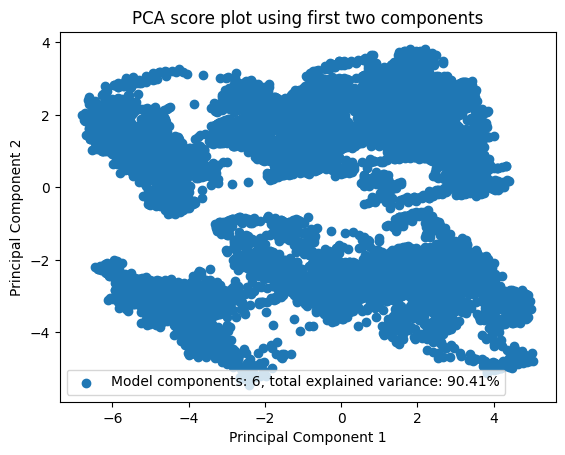

In [8]:
target_variance_pca = 0.90
n_components_pca = choose_n_components_by_variance(X, target_variance=target_variance_pca)

pca_model = pca_fit(X, n_components=n_components_pca)
Z_pca = pca_transform(X, pca_model)
evr_pca = pca_model["explained_variance_ratio"]

print("Original X shape:", X.shape)
print("PCA-transformed Z shape:", Z_pca.shape)
print("Selected PCA components:", n_components_pca)
print("Explained variance ratio:", evr_pca.values)
print("Cumulative explained variance:", evr_pca.cumsum().values)
print("Total explained variance:", evr_pca.sum())
print(Z_pca.head())

plt.scatter(Z_pca["Z1"], Z_pca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA score plot using first two components")
plt.legend([f"Model components: {n_components_pca}, total explained variance: {evr_pca.sum()*100:.2f}%"])
plt.show()


The score plot still shows only the first two principal components, but the monitoring model now uses enough components to explain the selected cumulative variance target. This separates visualization from the actual fault detection model.


### Q and T2 statistics for PCA

PCA Q threshold (99.0%): 10.239
PCA T2 threshold (99.0%): 21.876


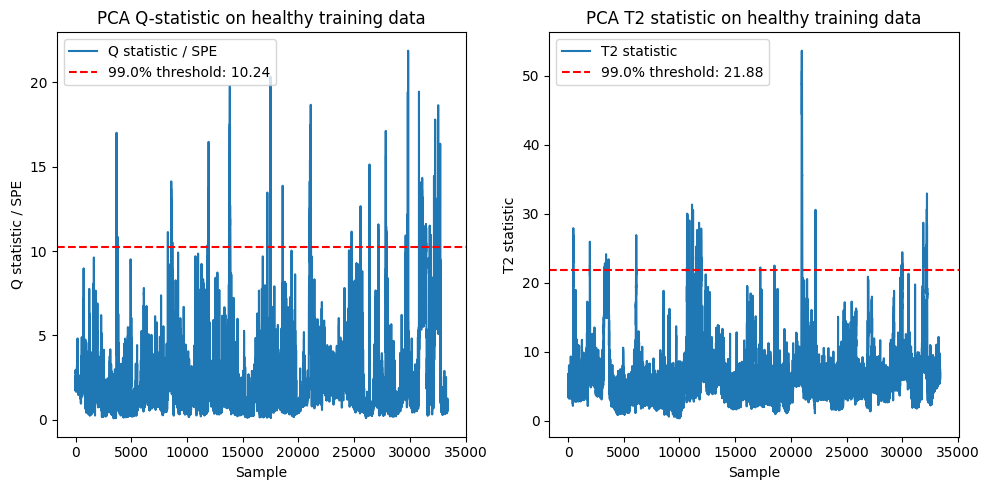

In [9]:
# Q-statistic / SPE
q_train_pca = q_statistic(X, Z_pca, pca_model)

# Hotelling's T2 statistic
t2_train_pca = t2_statistic(Z_pca, pca_model)

# Use a stricter empirical limit for fault detection.
# 95% means about 5% expected alarms on healthy calibration data.
threshold_quantile = 0.99
threshold_q_pca = q_train_pca.quantile(threshold_quantile)
threshold_t2_pca = t2_train_pca.quantile(threshold_quantile)

print(f"PCA Q threshold ({threshold_quantile:.1%}): {threshold_q_pca:.3f}")
print(f"PCA T2 threshold ({threshold_quantile:.1%}): {threshold_t2_pca:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(q_train_pca, label="Q statistic / SPE")
axes[0].axhline(y=threshold_q_pca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_q_pca:.2f}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("PCA Q-statistic on healthy training data")
axes[0].legend()

axes[1].plot(t2_train_pca, label="T2 statistic")
axes[1].axhline(y=threshold_t2_pca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_t2_pca:.2f}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("PCA T2 statistic on healthy training data")
axes[1].legend()

plt.tight_layout()
plt.show()


A 95% empirical threshold gives roughly 5% expected alarms even on healthy data. For fault detection, 99% or 99.5% is usually a better starting point. The threshold must be estimated from healthy training/calibration data only.


## DPCA transform

Original X shape: (33397, 23)
DPCA-transformed Z shape: (33392, 7)
Selected DPCA components: 7
Explained variance ratio: [0.35273153 0.21515187 0.17222309 0.0847148  0.03795777 0.03221973
 0.01966903]
Cumulative explained variance: [0.35273153 0.5678834  0.74010649 0.82482129 0.86277906 0.89499879
 0.91466783]
Total explained variance: 0.9146678269001918
         Z1        Z2        Z3        Z4        Z5        Z6        Z7
5  5.643067 -5.641922 -6.435689  0.503579  0.998761 -0.710301 -0.722277
6  5.494519 -5.602690 -6.377642  0.550499  1.198324 -0.649845 -0.770081
7  5.346710 -5.588183 -6.350881  0.577187  1.433544 -0.556260 -0.838484
8  5.199090 -5.590620 -6.364563  0.559471  1.685477 -0.449171 -0.919177
9  4.962191 -5.572595 -6.351348  0.518840  1.894151 -0.366500 -0.961030


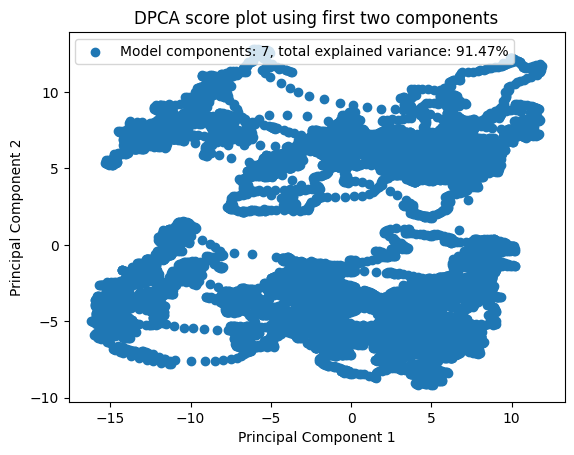

In [10]:
time_lags = 5
target_variance_dpca = 0.90

# Select DPCA components from the standardized lagged healthy training matrix.
X_lagged_for_selection = build_lagged_matrix(X, time_lags)
X_lagged_for_selection = (X_lagged_for_selection - X_lagged_for_selection.mean()) / X_lagged_for_selection.std().replace(0, 1e-12)
n_components_dpca = choose_n_components_by_variance(X_lagged_for_selection, target_variance=target_variance_dpca)

dpca_model = dpca_fit(X, n_components=n_components_dpca, time_lags=time_lags)
evr_dpca = dpca_model["explained_variance_ratio"]
Z_dpca = dpca_transform(X, dpca_model)

print("Original X shape:", X.shape)
print("DPCA-transformed Z shape:", Z_dpca.shape)
print("Selected DPCA components:", n_components_dpca)
print("Explained variance ratio:", evr_dpca.values)
print("Cumulative explained variance:", evr_dpca.cumsum().values)
print("Total explained variance:", evr_dpca.sum())
print(Z_dpca.head())

plt.scatter(Z_dpca["Z1"], Z_dpca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DPCA score plot using first two components")
plt.legend([f"Model components: {n_components_dpca}, total explained variance: {evr_dpca.sum()*100:.2f}%"])
plt.show()


### Q and T2 statistic for DPCA

DPCA Q threshold (99.0%): 42.174
DPCA T2 threshold (99.0%): 24.642


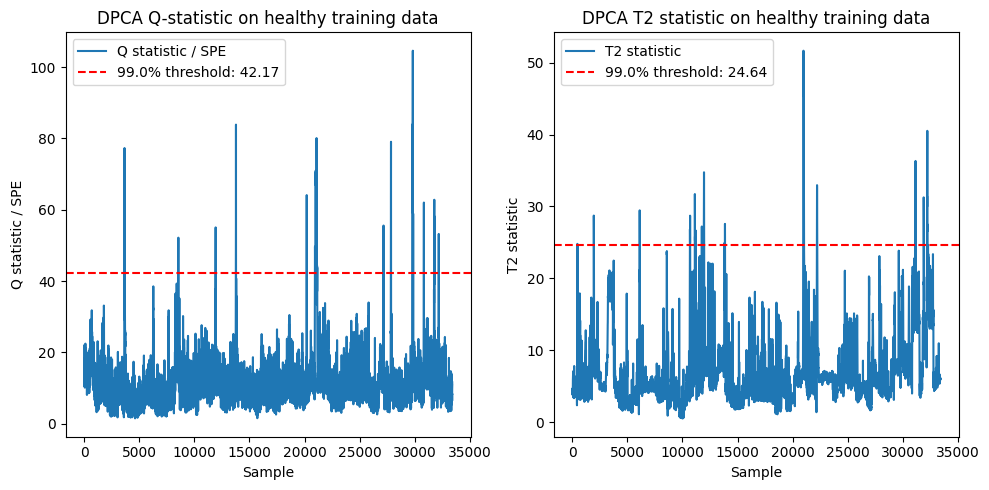

In [11]:
X_lagged = dpca_prepare_matrix(X, dpca_model)

q_values_dpca = q_statistic(X_lagged, Z_dpca, dpca_model["pca_model"])
t2_values_dpca = t2_statistic(Z_dpca, dpca_model["pca_model"])

threshold_q_dpca = q_values_dpca.quantile(threshold_quantile)
threshold_t2_dpca = t2_values_dpca.quantile(threshold_quantile)

print(f"DPCA Q threshold ({threshold_quantile:.1%}): {threshold_q_dpca:.3f}")
print(f"DPCA T2 threshold ({threshold_quantile:.1%}): {threshold_t2_dpca:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(q_values_dpca, label="Q statistic / SPE")
axes[0].axhline(y=threshold_q_dpca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_q_dpca:.2f}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("DPCA Q-statistic on healthy training data")
axes[0].legend()

axes[1].plot(t2_values_dpca, label="T2 statistic")
axes[1].axhline(y=threshold_t2_dpca, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_t2_dpca:.2f}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("DPCA T2 statistic on healthy training data")
axes[1].legend()

plt.tight_layout()
plt.show()


## FDA Training

In [12]:

# FDA training data.
# Train FDA on labelled FaultyCase1 only, and treat FaultyCase2-6 as held-out fault cases below.
# This is a simple binary diagnosis setup: class 0 = healthy region, class 1 = fault region.

X_train_list = []
y_train_list = []

fda_train_case = "FaultyCase1"

for name, dataset in FC1sets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()
    windows = normalize_fault_windows(se_windows[fda_train_case][name])

    sample_index = np.arange(len(df))
    fault_mask = is_in_fault_window(sample_index, se_windows[fda_train_case][name])

    healthy = df.loc[~fault_mask]
    faulty = df.loc[fault_mask]

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, axis=0, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_training_dataset = TimeSeriesDataset(
    name="FDA_training_data_FaultyCase1",
    sensors=X_fda,
    metadata={"description": "Pooled healthy/fault labelled data from FaultyCase1 only"},
)

fda_model = FDAModel()
fda_model.fit(fda_training_dataset, y_fda)


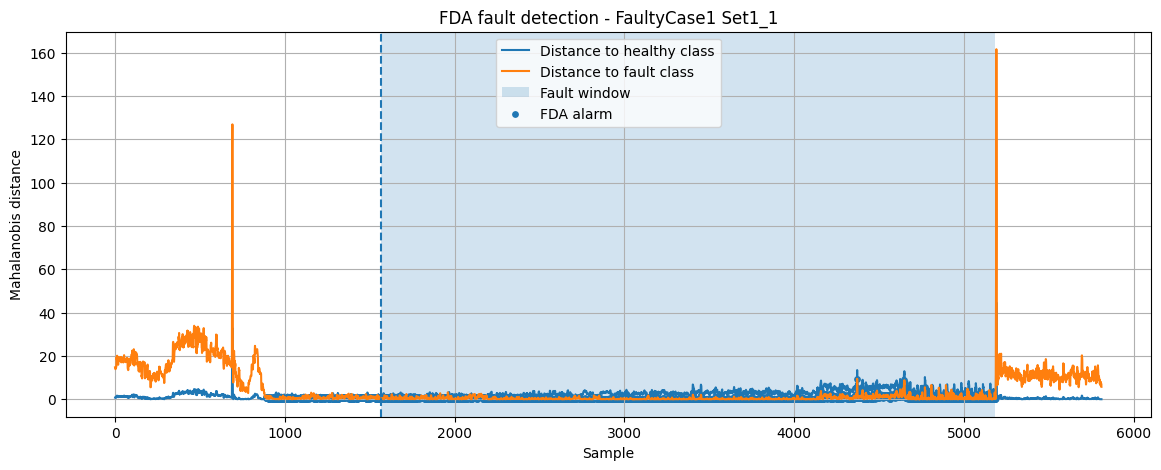

In [13]:

case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

dataset = FC1sets[set_name]
pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

plt.figure(figsize=(14, 5))
plt.plot(d_healthy, label="Distance to healthy class")
plt.plot(d_fault, label="Distance to fault class")
add_fault_spans(plt.gca(), windows, label="Fault window")

alarm_idx = np.where(pred == 1)[0]
plt.scatter(alarm_idx, d_fault[alarm_idx], s=15, label="FDA alarm")

plt.title(f"FDA fault detection - {case_name} {set_name}")
plt.xlabel("Sample")
plt.ylabel("Mahalanobis distance")
plt.legend()
plt.grid(True)
plt.show()


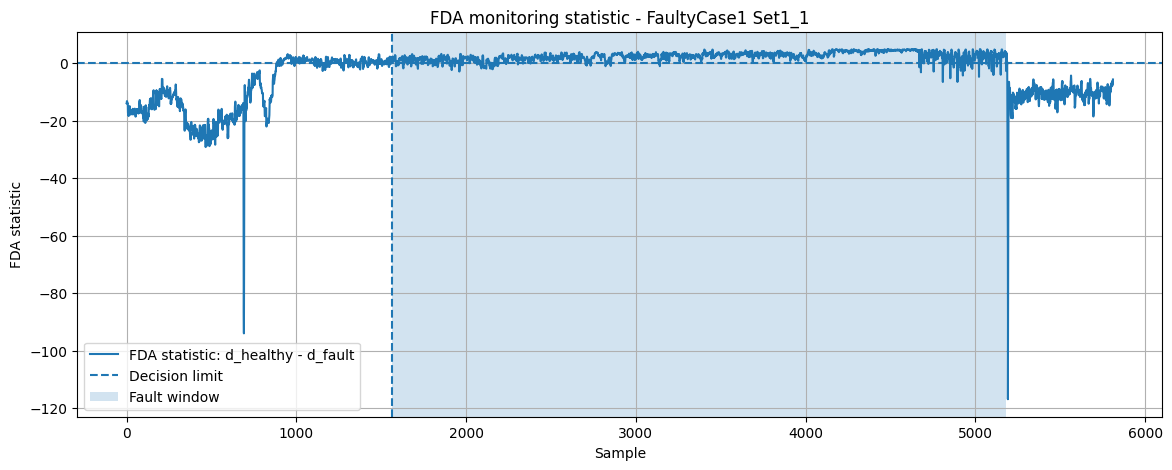

In [14]:

fda_stat = d_healthy - d_fault

plt.figure(figsize=(14, 5))
plt.plot(fda_stat, label="FDA statistic: d_healthy - d_fault")
plt.axhline(0, linestyle="--", label="Decision limit")
add_fault_spans(plt.gca(), windows, label="Fault window")

plt.title(f"FDA monitoring statistic - {case_name} {set_name}")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.legend()
plt.grid(True)
plt.show()


# Testing - Faulty cases

## Preprocessing of FC data

In [15]:

# Process all faulty/test sets with the SAME preprocessor fitted on healthy training data.
# This avoids train/test leakage.

fc_sets_processed = [
    {set_name: preprocessor.transform(dataset) for set_name, dataset in case_sets.items()}
    for case_sets in fc_sets_raw
]

# Use this variable in all Shewhart/PCA/DPCA test loops below.
fc_sets = fc_sets_processed

X_test_processed = fc_sets[0]["Set1_1"]
X_test_processed.sensors.head()


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.257477,-1.207282,-0.743139,-0.495792,-0.370479,-1.035621,-0.576704,-1.264366,-1.091749,-0.591350,...,0.658669,-1.325722,0.005809,0.295592,0.586574,-3.214151,-1.335846,-1.144366,-1.102621,-0.907107
1,-1.300984,-1.248340,-0.770215,-0.556165,-0.307856,-1.073498,-0.398625,-1.265313,-1.091737,-0.591351,...,0.658670,-1.331584,0.004874,0.295535,0.588436,-3.214543,-1.332469,-1.143350,-1.102576,-1.572943
2,-1.333812,-1.256920,-0.679517,-0.579059,-0.245237,-1.103890,-0.478125,-1.266177,-1.091725,-0.591352,...,0.658670,-1.337498,0.003939,0.295480,0.590300,-3.214935,-1.327082,-1.142332,-1.102531,-2.294266
3,-1.342197,-1.268204,-0.549557,-0.478589,-0.182625,-1.131786,-0.611685,-1.266465,-1.091713,-0.591354,...,0.658671,-1.343307,0.003005,0.295425,0.592162,-3.215327,-1.321691,-1.141315,-1.102486,-2.312762
4,-1.357543,-1.298204,-0.557684,-0.336952,-0.137716,-1.159683,-0.474945,-1.266589,-1.091701,-0.591355,...,0.658671,-1.349116,0.002070,0.295368,0.594026,-3.215719,-1.316304,-1.140298,-1.102441,-0.666666


## Shewhart testing

In [16]:
# Shewhart evaluation on all faulty/test sets.
# Uses preprocessed fault data, all sensors, and all labelled fault windows.

shew_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        sensor_alarm_matrix = (X_fault > shewhart_upper) | (X_fault < shewhart_lower)
        shew_alarm_mask = sensor_alarm_matrix.any(axis=1).to_numpy()
        sample_index = X_fault.index.to_numpy()

        shew_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Sensors Used": X_fault.shape[1],
            "Detection delay Shewhart": first_detection_delay(
                shew_alarm_mask,
                windows,
                sample_index,
            ),
            "Shewhart alarm samples": int(shew_alarm_mask.sum()),
            "Shewhart cell anomalies": int(sensor_alarm_matrix.to_numpy().sum()),
            "Shewhart false alarms": count_false_alarms(
                shew_alarm_mask,
                windows,
                sample_index,
            ),
        })

shew_results_df = pd.DataFrame(shew_results)
print("Shewhart Results:")
shew_results_df


Shewhart Results:


,Case,Set,Samples,Sensors Used,Detection delay Shewhart,Shewhart alarm samples,Shewhart cell anomalies,Shewhart false alarms
0,FaultyCase1,Set1_1,5811,23,0,3632,5886,1778
1,FaultyCase1,Set1_2,4467,23,21,1685,5966,273
2,FaultyCase1,Set1_3,4321,23,208,1091,4158,190
3,FaultyCase2,Set2_1,9192,23,27,4702,4945,2781
4,FaultyCase2,Set2_2,3496,23,2232,94,156,94
5,FaultyCase2,Set2_3,3421,23,0,878,961,468
6,FaultyCase3,Set3_1,9090,23,0,8600,32232,1383
7,FaultyCase3,Set3_2,6272,23,0,6134,22991,595
8,FaultyCase3,Set3_3,10764,23,33,9486,39494,550
9,FaultyCase4,Set4_1,7208,23,0,6359,17402,1017


## PCA testing

PCA on Set1_1: Q-statistic detection delay: 24 samples
PCA on Set1_1: T2 statistic detection delay: 2594 samples
PCA on Set1_1: Number of Q-statistic alarm samples: 2013 of 5811 samples
PCA on Set1_1: Number of T2 statistic alarm samples: 1065 of 5811 samples


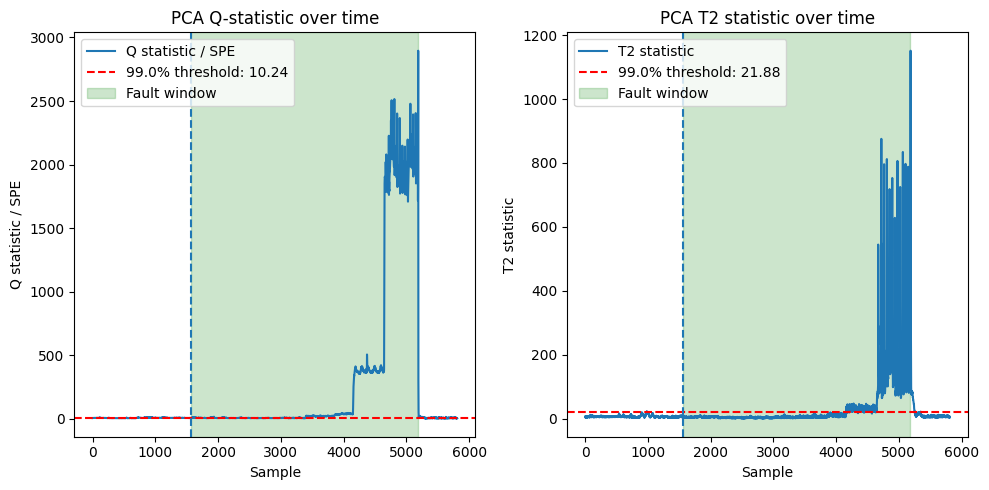

In [17]:
# A single PCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

PCA_X_FC1_1 = fc_sets[0][set_name].sensors
PCA_Z_FC1_1 = pca_transform(PCA_X_FC1_1, pca_model)
PCA_q_FC1_1 = q_statistic(PCA_X_FC1_1, PCA_Z_FC1_1, pca_model)
PCA_t2_FC1_1 = t2_statistic(PCA_Z_FC1_1, pca_model)

q_alarm_mask = (PCA_q_FC1_1 > threshold_q_pca).to_numpy()
t2_alarm_mask = (PCA_t2_FC1_1 > threshold_t2_pca).to_numpy()

print(f"PCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, PCA_q_FC1_1.index)} samples")
print(f"PCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, PCA_t2_FC1_1.index)} samples")
print(f"PCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(PCA_q_FC1_1)} samples")
print(f"PCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(PCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(PCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_q_pca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("PCA Q-statistic over time")
axes[0].legend()

axes[1].plot(PCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_t2_pca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("PCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [18]:

# PCA evaluation on all faulty/test sets.
# Uses all fault windows and preserves sample index.

pca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        Z_fault = pca_transform(X_fault, pca_model)
        q_fault = q_statistic(X_fault, Z_fault, pca_model)
        t2_fault = t2_statistic(Z_fault, pca_model)

        q_alarm_mask = (q_fault > threshold_q_pca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_pca).to_numpy()

        pca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Q": first_detection_delay(q_alarm_mask, windows, q_fault.index),
            "Detection delay T2": first_detection_delay(t2_alarm_mask, windows, t2_fault.index),
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "Q false alarms": count_false_alarms(q_alarm_mask, windows, q_fault.index),
            "T2 false alarms": count_false_alarms(t2_alarm_mask, windows, t2_fault.index),
        })

pca_results_df = pd.DataFrame(pca_results)
print("PCA Results:")
pca_results_df


PCA Results:


,Case,Set,Samples,Detection delay Q,Detection delay T2,Q alarm samples,T2 alarm samples,Q false alarms,T2 false alarms
0,FaultyCase1,Set1_1,5811,24,2594,2013,1065,182,72
1,FaultyCase1,Set1_2,4467,1531,2120,1682,962,361,149
2,FaultyCase1,Set1_3,4321,208,2409,1094,679,90,88
3,FaultyCase2,Set2_1,9192,469,4835,5338,46,2577,46
4,FaultyCase2,Set2_2,3496,15,2232,684,6,246,6
5,FaultyCase2,Set2_3,3421,34,2285,711,58,72,58
6,FaultyCase3,Set3_1,9090,3,112,7654,7259,447,195
7,FaultyCase3,Set3_2,6272,0,11,5922,3381,534,324
8,FaultyCase3,Set3_3,10764,16,115,9108,9014,168,347
9,FaultyCase4,Set4_1,7208,233,480,5777,2076,862,35


In [19]:
# # This plots Q and T2 statistics for all sets in all cases

# for case_name, case_sets in zip(se_windows.keys(), fc_sets):
#     for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
#         X_fault = case_sets[set_name].sensors
#         Z_fault = pca_transform(X_fault, pca_model)
#         q_fault = q_statistic(X_fault, Z_fault)
#         t2_fault = t2_statistic(Z_fault)

#         n_q_anomalies = np.sum(q_fault > threshold_q_pca)
#         n_t2_anomalies = np.sum(t2_fault > threshold_t2_pca)

#         print(f"PCA on {case_name} {set_name}: Number of Q-statistic anomalies: {n_q_anomalies} of {len(X_fault)} samples")
#         print(f"PCA on {case_name} {set_name}: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(X_fault)} samples")

#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.plot(q_fault, label='Q statistic / SPE')
#         plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("Q statistic / SPE")
#         plt.title(f"PCA Q-statistic over time - {case_name} {set_name}")
#         plt.legend()

#         plt.subplot(1, 2, 2)
#         plt.plot(t2_fault, label='T2 statistic')
#         plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("T2 statistic")
#         plt.title(f"PCA T2 statistic over time - {case_name} {set_name}")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

## DPCA testing

DPCA on Set1_1: Q-statistic detection delay: 0 samples
DPCA on Set1_1: T2 statistic detection delay: 2597 samples
DPCA on Set1_1: Number of Q-statistic alarm samples: 3887 of 5806 samples
DPCA on Set1_1: Number of T2 statistic alarm samples: 1101 of 5806 samples


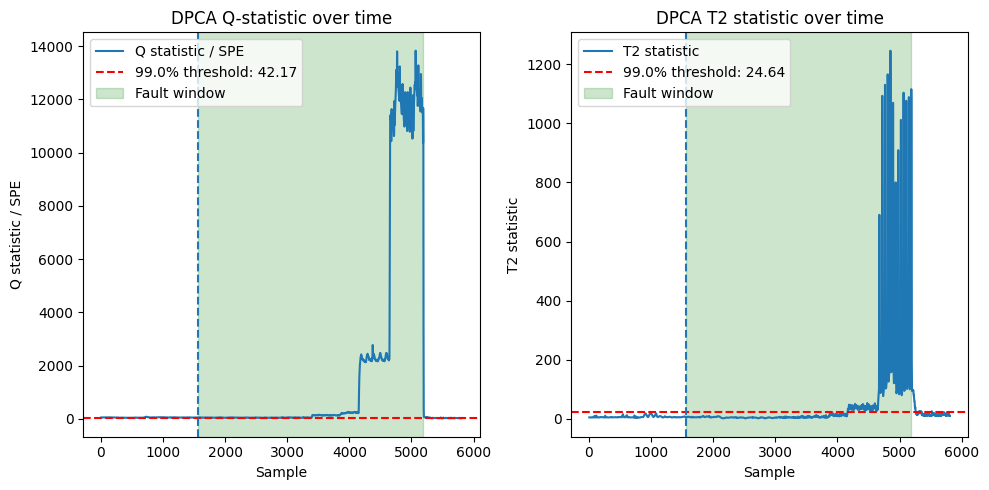

In [20]:
# A single DPCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

DPCA_X_FC1_1 = fc_sets[0][set_name].sensors
DPCA_X_FC1_1_lagged = dpca_prepare_matrix(DPCA_X_FC1_1, dpca_model)
DPCA_Z_FC1_1 = dpca_transform(DPCA_X_FC1_1, dpca_model)
DPCA_q_FC1_1 = q_statistic(DPCA_X_FC1_1_lagged, DPCA_Z_FC1_1, dpca_model["pca_model"])
DPCA_t2_FC1_1 = t2_statistic(DPCA_Z_FC1_1, dpca_model["pca_model"])

q_alarm_mask = (DPCA_q_FC1_1 > threshold_q_dpca).to_numpy()
t2_alarm_mask = (DPCA_t2_FC1_1 > threshold_t2_dpca).to_numpy()

print(f"DPCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, DPCA_q_FC1_1.index)} samples")
print(f"DPCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, DPCA_t2_FC1_1.index)} samples")
print(f"DPCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(DPCA_q_FC1_1)} samples")
print(f"DPCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(DPCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(DPCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_dpca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_q_dpca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("DPCA Q-statistic over time")
axes[0].legend()

axes[1].plot(DPCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_dpca, color='r', linestyle='--', label=f'{threshold_quantile:.1%} threshold: {threshold_t2_dpca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("DPCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [21]:

# DPCA evaluation on all faulty/test sets.
# DPCA statistics start at original sample index = time_lags, so use the Series index for delays and false alarms.

dpca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        X_fault_lagged = dpca_prepare_matrix(X_fault, dpca_model)
        Z_fault = dpca_transform(X_fault, dpca_model)
        q_fault = q_statistic(X_fault_lagged, Z_fault, dpca_model["pca_model"])
        t2_fault = t2_statistic(Z_fault, dpca_model["pca_model"])

        q_alarm_mask = (q_fault > threshold_q_dpca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_dpca).to_numpy()

        dpca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Q": first_detection_delay(q_alarm_mask, windows, q_fault.index),
            "Detection delay T2": first_detection_delay(t2_alarm_mask, windows, t2_fault.index),
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "Q false alarms": count_false_alarms(q_alarm_mask, windows, q_fault.index),
            "T2 false alarms": count_false_alarms(t2_alarm_mask, windows, t2_fault.index),
        })

dpca_results_df = pd.DataFrame(dpca_results)
print("DPCA Results:")
dpca_results_df


DPCA Results:


,Case,Set,Samples,Detection delay Q,Detection delay T2,Q alarm samples,T2 alarm samples,Q false alarms,T2 false alarms
0,FaultyCase1,Set1_1,5811,0,2597,3887,1101,1225,82
1,FaultyCase1,Set1_2,4467,1528,2138,1561,1028,213,178
2,FaultyCase1,Set1_3,4321,1814,2413,1123,682,94,94
3,FaultyCase2,Set2_1,9192,501,507,4634,60,2594,22
4,FaultyCase2,Set2_2,3496,1840,2232,414,53,73,53
5,FaultyCase2,Set2_3,3421,1060,333,655,127,53,117
6,FaultyCase3,Set3_1,9090,0,114,8278,7369,1061,274
7,FaultyCase3,Set3_2,6272,662,0,4489,4874,127,490
8,FaultyCase3,Set3_3,10764,35,104,9091,9222,155,383
9,FaultyCase4,Set4_1,7208,0,482,6308,2344,970,40


## FDA Testing

In [22]:

# FDA threshold from healthy training class.
# Held-out evaluation excludes FaultyCase1, because the FDA model was trained on FaultyCase1.

_, _, d_healthy_train, _, margin_train = fda_model.predict(fda_training_dataset)
healthy_mask = y_fda == 0
threshold_fda = np.quantile(d_healthy_train[healthy_mask], 0.95)

fda_results = []
heldout_cases = list(se_windows.keys())[1:]  # FaultyCase2-6
heldout_sets = fc_sets_raw[1:]

for case_name, case_sets in zip(heldout_cases, heldout_sets):
    for set_name, dataset in case_sets.items():
        windows = se_windows[case_name][set_name]
        pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

        fda_alarm_mask = d_healthy > threshold_fda
        sample_index = np.arange(len(fda_alarm_mask))

        fda_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(d_healthy),
            "Detection delay FDA": first_detection_delay(fda_alarm_mask, windows, sample_index),
            "FDA alarm samples": int(np.sum(fda_alarm_mask)),
            "FDA false alarms": count_false_alarms(fda_alarm_mask, windows, sample_index),
        })

fda_results_df = pd.DataFrame(fda_results)
fda_results_df


,Case,Set,Samples,Detection delay FDA,FDA alarm samples,FDA false alarms
0,FaultyCase2,Set2_1,9192,385,5229,1579
1,FaultyCase2,Set2_2,3496,7,1185,266
2,FaultyCase2,Set2_3,3421,1214,1024,204
3,FaultyCase3,Set3_1,9090,121,8545,1516
4,FaultyCase3,Set3_2,6272,0,4374,373
5,FaultyCase3,Set3_3,10764,291,9581,1201
6,FaultyCase4,Set4_1,7208,0,3682,1188
7,FaultyCase4,Set4_2,4451,325,2942,458
8,FaultyCase4,Set4_3,3661,323,2051,75
9,FaultyCase5,Set5_1,2541,0,2265,1539


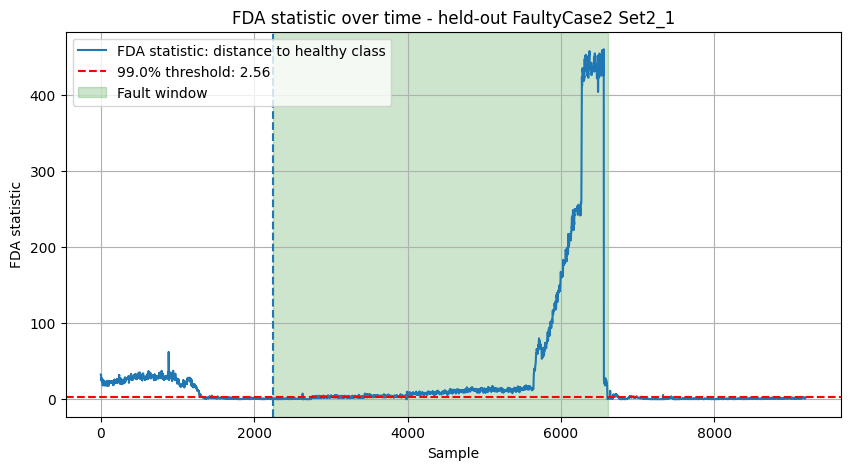

In [23]:
case_name = "FaultyCase2"
set_name = "Set2_1"
windows = se_windows[case_name][set_name]

dataset = FC2sets[set_name]
pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

plt.figure(figsize=(10, 5))
plt.plot(d_healthy, label="FDA statistic: distance to healthy class")
plt.axhline(y=threshold_fda, color="r", linestyle="--", label=f"{threshold_quantile:.1%} threshold: {threshold_fda:.2f}")
add_fault_spans(plt.gca(), windows, color="g", label="Fault window")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.title(f"FDA statistic over time - held-out {case_name} {set_name}")
plt.legend()
plt.grid(True)
plt.show()
